## Данные

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from pathlib import Path
import json

In [2]:
news_old = pd.read_parquet('news_descriptions/news_collection_old.parquet')
news_old['date'] = pd.to_datetime(news_old['date']).dt.normalize()

gpt4o = pd.read_json('news_descriptions/news_descriptions_GPT4o.json').transpose()

valid_tickers = set(pd.read_json('tickers_description.json', orient='index').index)

def clean_tickers(raw):
    if not isinstance(raw, list): return []
    return [t.strip('#$') for t in raw if t.strip('#$') in valid_tickers]

sentiment_news = pd.concat([news_old.reset_index(drop=True), gpt4o.reset_index(drop=True)], axis=1)[:15000]
sentiment_news = sentiment_news[sentiment_news['body'].astype(str) != '""']
sentiment_news['tickers']         = sentiment_news['tickers'].apply(clean_tickers)
sentiment_news['sentiment_score'] = pd.to_numeric(sentiment_news['sentiment_score'], errors='coerce')

print('sentiment_news:', sentiment_news.shape)
sentiment_news[['date', 'body', 'tickers', 'sentiment_score']].head()

sentiment_news: (14772, 11)


,date,body,tickers,sentiment_score
0,2024-09-09,"""После падения добычи в 2022-2023 годах Газпро...",[GAZP],-0.5
1,2024-09-09,""" Рейтинг акций комьюнити РДВ. #опрос """,[],0.0
2,2024-09-09,"""Нефть Brent упала до $71, Urals - до $60 за б...",[],-0.5
3,2024-09-09,"""️ Ставка ЦБ вряд ли уйдёт выше 18%. ЦБ переже...",[MOEX],0.0
4,2024-09-09,"""Эксперты клуба RDV PREMIUM 361° дали коммента...","[SMLT, LSRG, PIKK]",0.5


In [3]:
moex = pd.read_csv('MOEX.csv', encoding='cp1251', sep=';', engine='python', on_bad_lines='warn')
moex['date']   = pd.to_datetime(moex['TRADEDATE'], dayfirst=True)
moex['close']  = moex['CLOSE'].astype(str).str.replace(',', '.').astype(float)
moex['return'] = moex['close'].pct_change()
moex = moex[['date', 'close', 'return']].dropna().reset_index(drop=True)

print('moex:', moex.shape, '|', moex['date'].min().date(), '→', moex['date'].max().date())
moex.head()

moex: (728, 3) | 2022-01-11 → 2024-12-16


,date,close,return
0,2022-01-11,3785.29,0.012467
1,2022-01-12,3829.95,0.011798
2,2022-01-13,3674.73,-0.040528
3,2022-01-14,3596.98,-0.021158
4,2022-01-17,3560.35,-0.010184


In [4]:
daily_sentiment = (
    sentiment_news
    .groupby('date')['sentiment_score']
    .mean()
    .reset_index()
    .rename(columns={'sentiment_score': 'sentiment_index'})
)

final_df = moex.merge(daily_sentiment, on='date', how='inner').reset_index(drop=True)
print('final_df:', final_df.shape)
final_df.head()

final_df: (593, 4)


,date,close,return,sentiment_index
0,2022-06-14,2289.75,0.001851,0.300000
1,2022-06-15,2318.96,0.012757,-0.331250
2,2022-06-16,2369.75,0.021902,0.572727
3,2022-06-17,2353.98,-0.006655,0.180000
4,2022-06-20,2404.40,0.021419,0.078947


## Тест на стационарность (ADF)

Перед корреляционным и Грейнджер-анализом проверяем, что ряды стационарны.

In [5]:
for col in ['return', 'sentiment_index']:
    stat, p, *_ = adfuller(final_df[col].dropna())
    status = 'стационарен ✓' if p < 0.05 else 'нестационарен ✗'
    print(f'{col:<20} ADF={stat:7.3f}  p={p:.4f}  → {status}')

return               ADF=-12.317  p=0.0000  → стационарен ✓
sentiment_index      ADF= -4.377  p=0.0003  → стационарен ✓


## Корреляционный анализ

In [6]:
r_p, p_p = stats.pearsonr( final_df['sentiment_index'], final_df['return'])
r_s, p_s = stats.spearmanr(final_df['sentiment_index'], final_df['return'])

print(f'Pearson:  r={r_p:.3f}  p={p_p:.4f}')
print(f'Spearman: r={r_s:.3f}  p={p_s:.4f}')

Pearson:  r=0.184  p=0.0000
Spearman: r=0.169  p=0.0000


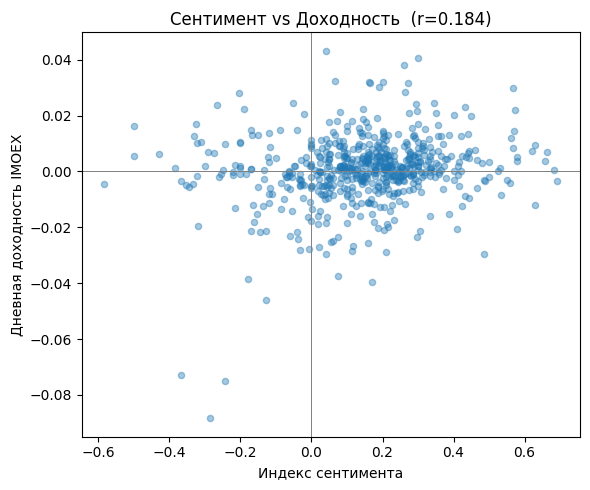

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(final_df['sentiment_index'], final_df['return'], alpha=0.4, s=20)
ax.axhline(0, color='grey', linewidth=0.7)
ax.axvline(0, color='grey', linewidth=0.7)
ax.set_xlabel('Индекс сентимента')
ax.set_ylabel('Дневная доходность IMOEX')
ax.set_title(f'Сентимент vs Доходность  (r={r_p:.3f})')
plt.tight_layout()
plt.show()

## Лаговый анализ

Проверяем, насколько сентимент дня T предсказывает доходность дня T+lag.

In [8]:
lag_results = []
for lag in range(0, 8):
    s = final_df['sentiment_index'].shift(lag)
    valid = s.notna()
    r, p = stats.pearsonr(s[valid], final_df['return'][valid])
    lag_results.append({'lag': lag, 'r': round(r, 4), 'p': round(p, 4)})

lag_df = pd.DataFrame(lag_results).set_index('lag')
print(lag_df)

          r       p
lag                
0    0.1843  0.0000
1    0.0681  0.0978
2    0.1038  0.0116
3    0.0251  0.5421
4    0.0640  0.1207
5    0.0014  0.9726
6   -0.0163  0.6935
7    0.0189  0.6487


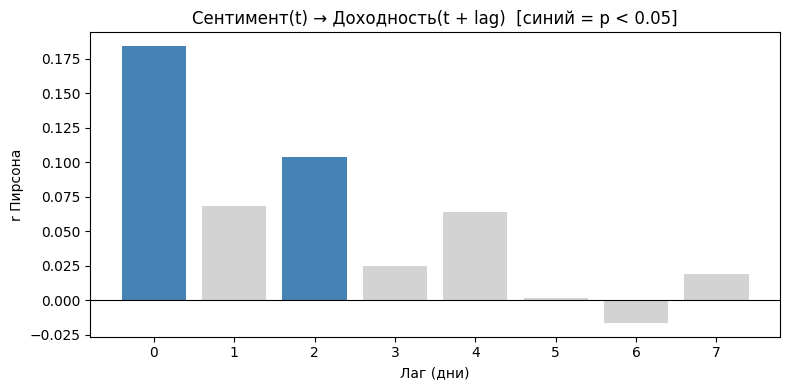

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if p < 0.05 else 'lightgrey' for p in lag_df['p']]
ax.bar(lag_df.index, lag_df['r'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Лаг (дни)')
ax.set_ylabel('r Пирсона')
ax.set_title('Сентимент(t) → Доходность(t + lag)  [синий = p < 0.05]')
plt.tight_layout()
plt.show()

## Тест Грейнджера

Проверяем, является ли сентимент причиной (в смысле Грейнджера) изменений доходности.

In [10]:
data = final_df[['return', 'sentiment_index']].dropna().values
granger = grangercausalitytests(data, maxlag=5, verbose=False)

for lag, res in granger.items():
    f, p, *_ = res[0]['ssr_ftest']
    sig = '✓' if p < 0.05 else ' '
    print(f'lag={lag}  F={f:6.3f}  p={p:.4f}  {sig}')

lag=1  F= 0.927  p=0.3361   
lag=2  F= 4.054  p=0.0178  ✓
lag=3  F= 2.019  p=0.1101   
lag=4  F= 1.684  p=0.1521   
lag=5  F= 1.533  p=0.1776   


/Users/artyom-olenev/Projects/news_analyzer/.venv/lib/python3.14/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## Визуализация: IMOEX и индекс сентимента

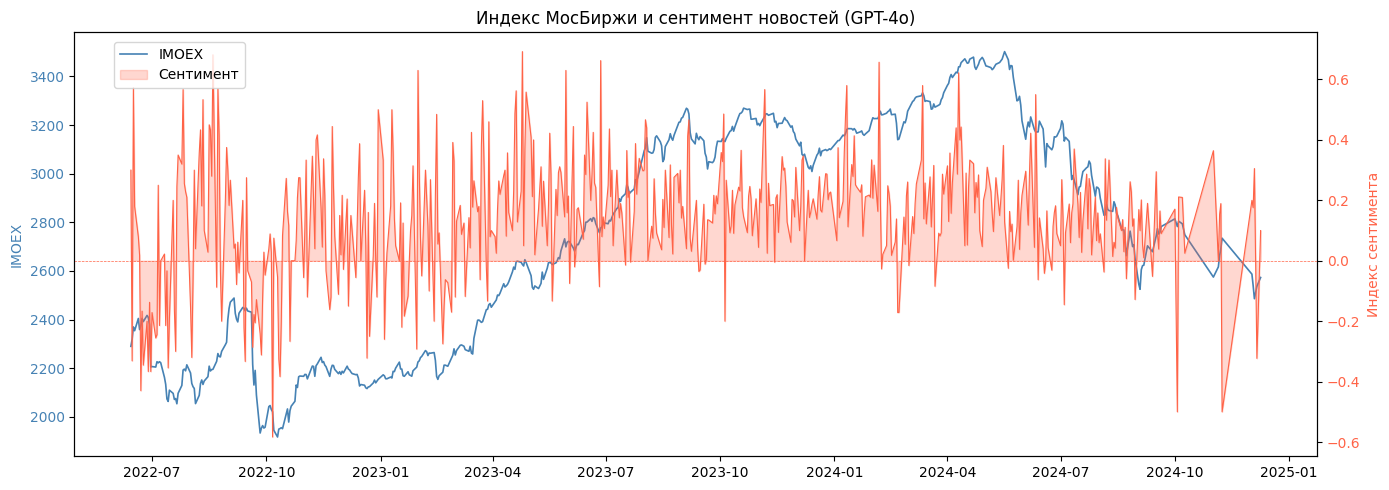

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(final_df['date'], final_df['close'], color='steelblue', linewidth=1.2)
ax1.set_ylabel('IMOEX', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.fill_between(final_df['date'], final_df['sentiment_index'], alpha=0.25, color='tomato')
ax2.plot(final_df['date'], final_df['sentiment_index'], color='tomato', linewidth=0.8)
ax2.axhline(0, color='tomato', linewidth=0.5, linestyle='--')
ax2.set_ylabel('Индекс сентимента', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_title('Индекс МосБиржи и сентимент новостей (GPT-4o)')
fig.legend(['IMOEX', 'Сентимент'], loc='upper left', bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.show()

---
## Анализ санкционных новостей

Ключевая гипотеза работы: санкционные новости влияют на рынок сильнее, чем обычные.

In [ ]:
SANCTION_KEYWORDS = [
    'санкци', 'санкционн', 'ограничени', 'SWIFT', 'свифт',
    'заморозк', 'эмбарго', 'embargo', 'отключ', 'блокировк',
    'потолок цен', 'price cap', 'OFAC', 'минфин США',
]

pattern = '|'.join(SANCTION_KEYWORDS)
sentiment_news['is_sanction'] = (
    sentiment_news['body'].astype(str).str.lower().str.contains(pattern, regex=True)
)

n_sanction = sentiment_news['is_sanction'].sum()
print(f'Санкционных новостей: {n_sanction} из {len(sentiment_news)} ({n_sanction/len(sentiment_news):.1%})')

### Два индекса сентимента: санкционные vs обычные

In [ ]:
sanction_daily = (
    sentiment_news[sentiment_news['is_sanction']]
    .groupby('date')['sentiment_score'].mean()
    .reset_index().rename(columns={'sentiment_score': 'sent_sanction'})
)
other_daily = (
    sentiment_news[~sentiment_news['is_sanction']]
    .groupby('date')['sentiment_score'].mean()
    .reset_index().rename(columns={'sentiment_score': 'sent_other'})
)

sanc_df = moex.merge(sanction_daily, on='date', how='inner').merge(other_daily, on='date', how='inner')
print('Дней с обоими типами:', len(sanc_df))
sanc_df.head()

### Сравнение корреляций

In [ ]:
r_sanc, p_sanc = stats.pearsonr(sanc_df['sent_sanction'], sanc_df['return'])
r_oth,  p_oth  = stats.pearsonr(sanc_df['sent_other'],    sanc_df['return'])

comparison = pd.DataFrame({
    'Тип новостей':  ['Санкционные', 'Обычные'],
    'Pearson r':     [round(r_sanc, 3), round(r_oth, 3)],
    'p-value':       [round(p_sanc, 4), round(p_oth, 4)],
})
print(comparison.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col, title, color in [
    (axes[0], 'sent_sanction', f'Санкционные (r={r_sanc:.3f})', 'tomato'),
    (axes[1], 'sent_other',    f'Обычные (r={r_oth:.3f})',       'steelblue'),
]:
    ax.scatter(sanc_df[col], sanc_df['return'], alpha=0.4, s=20, color=color)
    ax.axhline(0, color='grey', linewidth=0.7)
    ax.axvline(0, color='grey', linewidth=0.7)
    ax.set_xlabel('Сентимент')
    ax.set_title(title)

axes[0].set_ylabel('Доходность IMOEX')
plt.tight_layout()
plt.show()

### Асимметрия реакции: реагирует ли рынок быстрее на негативные санкции?

In [ ]:
sanc_df['sanction_neg'] = sanc_df['sent_sanction'] < 0
sanc_df['sanction_pos'] = sanc_df['sent_sanction'] > 0

mean_neg = sanc_df.loc[sanc_df['sanction_neg'], 'return'].mean()
mean_pos = sanc_df.loc[sanc_df['sanction_pos'], 'return'].mean()
mean_all = sanc_df['return'].mean()

print(f'Средняя доходность в дни негативных санкций: {mean_neg:+.4f}')
print(f'Средняя доходность в дни позитивных санкций: {mean_pos:+.4f}')
print(f'Средняя доходность всего:                    {mean_all:+.4f}')

t_stat, p_t = stats.ttest_ind(
    sanc_df.loc[sanc_df['sanction_neg'], 'return'],
    sanc_df.loc[sanc_df['sanction_pos'], 'return'],
)
print(f'\nt-тест разницы: t={t_stat:.3f}, p={p_t:.4f}')

### Визуализация: санкционный индекс и IMOEX

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(sanc_df['date'], sanc_df['close'], color='steelblue', linewidth=1.2)
ax1.set_ylabel('IMOEX', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.fill_between(sanc_df['date'], sanc_df['sent_sanction'], alpha=0.3, color='tomato')
ax2.plot(sanc_df['date'], sanc_df['sent_sanction'], color='tomato', linewidth=0.8)
ax2.axhline(0, color='tomato', linewidth=0.5, linestyle='--')
ax2.set_ylabel('Сентимент санкционных новостей', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_title('IMOEX и санкционный сентимент')
plt.tight_layout()
plt.show()